# **Frequency Domain Enhancement Pipeline**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def xray_frequency_pipeline(
    image_path,
    d0=40,
    alpha=0.6,
    amplification=2,
    show=True
):

    # 1. Grayscale
    original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if original is None:
        raise ValueError("Invalid image path")

    img = original.astype(np.float32)

    # 2. FFT
    f = np.fft.fft2(img)

    # 3. Shift spectrum to center
    fshift = np.fft.fftshift(f)

    # 4. Butterworth High-Pass Filter
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):

            D = np.sqrt((u - crow) ** 2 + (v - ccol) ** 2)

            H[u, v] = 1 / (1 + (d0 / (D + 1e-5)) ** 4)

    # Balanced frequency enhancement
    fshift_filtered = (alpha * fshift) + ((1 - alpha) * fshift * H)

    # Frequency amplification
    fshift_filtered *= amplification

    # 5. Inverse FFT-
    f_ishift = np.fft.ifftshift(fshift_filtered)

    img = np.fft.ifft2(f_ishift)

    img = np.abs(img)

    # 6. Normalize final output
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

    img = img.astype(np.uint8)

    # Display
    if show:

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.title("Original X-ray")
        plt.imshow(original, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.title("Frequency Enhanced X-ray")
        plt.imshow(img, cmap="gray")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return original, img

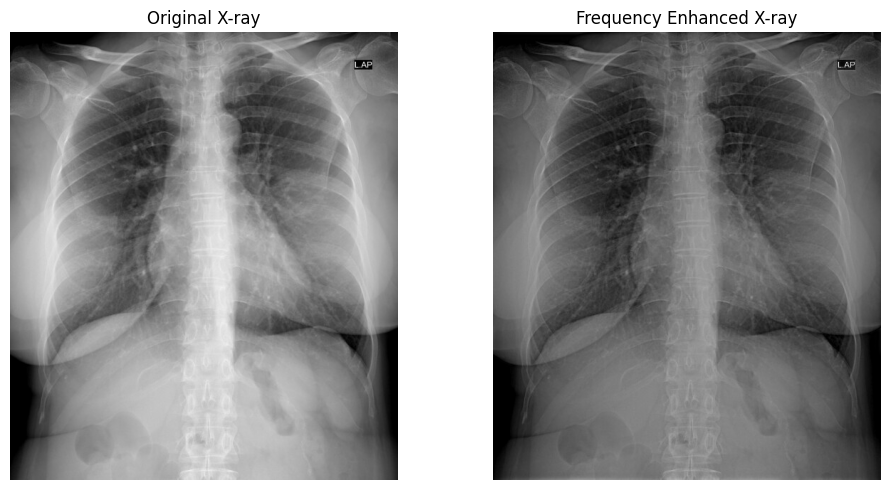

In [ ]:
original, enhanced = xray_frequency_pipeline("/content/fractured rib.jpeg")

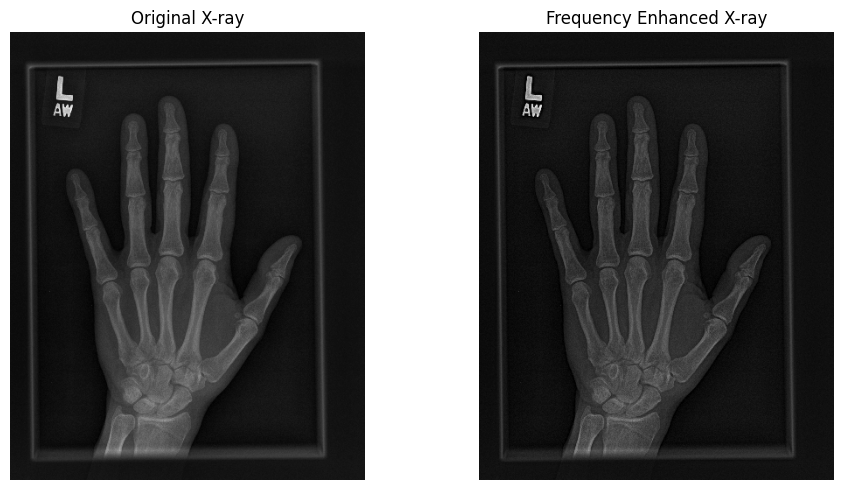

In [ ]:
original, enhanced = xray_frequency_pipeline("/content/image3.png")

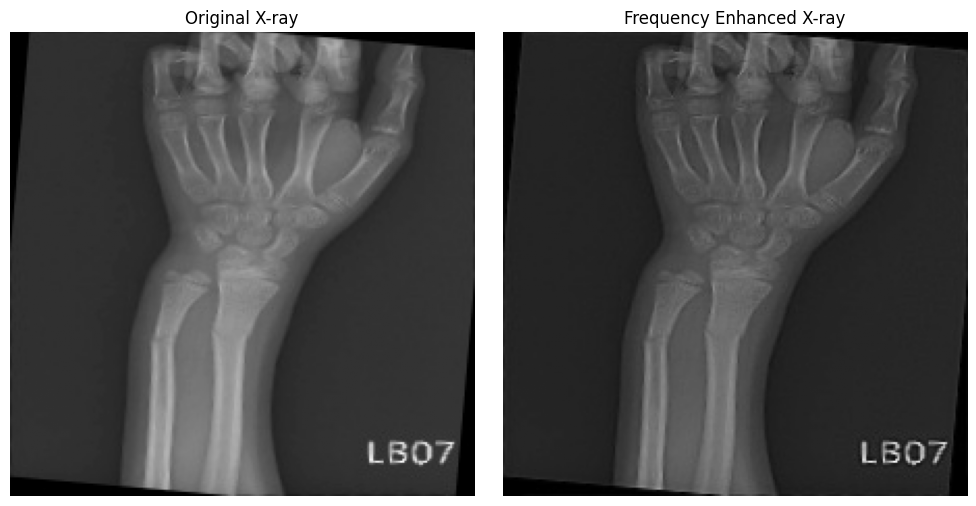

In [ ]:
original, enhanced = xray_frequency_pipeline("/content/fractured arm.jpg")

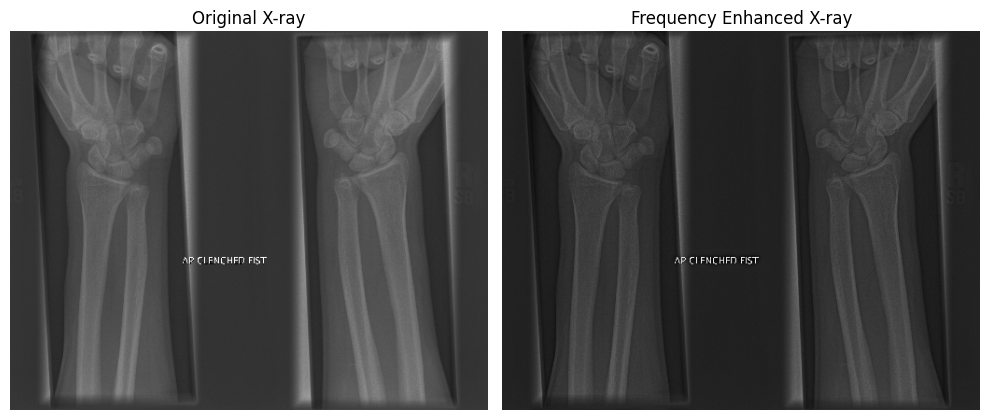

In [ ]:
original, enhanced = xray_frequency_pipeline("/content/image2 (1).png")

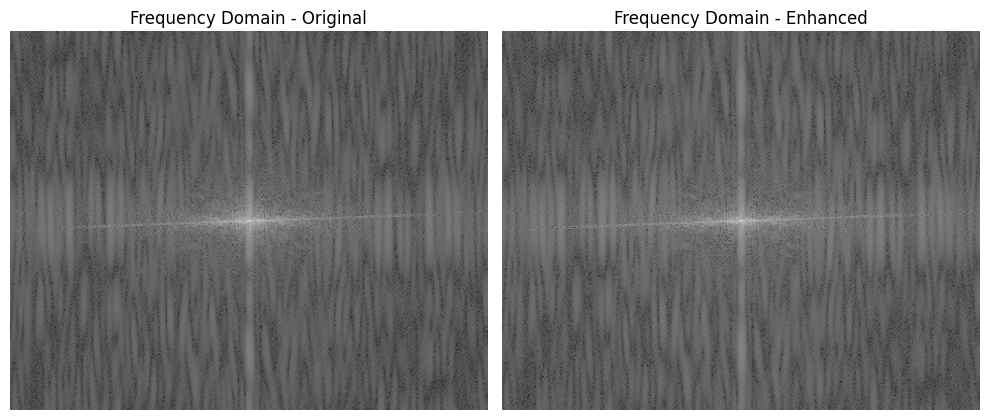

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

f = np.fft.fft2(original.astype(np.float32))
fshift_original = np.fft.fftshift(f)
magnitude_original = 20 * np.log(np.abs(fshift_original) + 1)

f2 = np.fft.fft2(enhanced.astype(np.float32))
fshift_enhanced = np.fft.fftshift(f2)
magnitude_enhanced = 20 * np.log(np.abs(fshift_enhanced) + 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Frequency Domain - Original")
plt.imshow(magnitude_original, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Frequency Domain - Enhanced")
plt.imshow(magnitude_enhanced, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

# **Observations :**
 1.	Used when the goal is to extract the outline of an organ or bone rather than the internal density.
 2.	Resulting images often look flat and dark to the human eye compared to standard X-rays.Not necessarily visually appealing
 3.	FFT is more mathematically intensive than simple spatial filters.
 4.	If the X-ray has periodic noise or electrical interference, you can remove them in the frequency domain.

